In [1]:
print("PRODIGY_ML_04 - Hand Gesture Recognition")
print("Task 4 started successfully!")

PRODIGY_ML_04 - Hand Gesture Recognition
Task 4 started successfully!


In [3]:
!pip install -q kaggle

In [4]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  20% /


In [5]:
!kaggle datasets download -d gti-upm/leapgestrecog -p /content

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:20<00:00, 110MB/s]



In [6]:
import zipfile
import os

zip_path = "/content/leapgestrecog.zip"
extract_path = "/content/leapgestrecog"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
import os

dataset_path = "/content/leapgestrecog"

print("Main folders:")
print(os.listdir(dataset_path))

Main folders:
['leapGestRecog', 'leapgestrecog']


In [8]:
import os

dataset_path = "/content/leapgestrecog"

for item in os.listdir(dataset_path):
    print(item)

leapGestRecog
leapgestrecog


In [9]:
import os

dataset_path = "/content/leapgestrecog"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

leapgestrecog/
  leapGestRecog/
    00/
    01/
    08/
    05/
    03/
    09/
    06/
    02/
    07/
    04/
  leapgestrecog/
    leapGestRecog/


In [10]:
import os

dataset_path = "/content/leapgestrecog"

# Find all folders containing images
gesture_folders = []

for root, dirs, files in os.walk(dataset_path):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if image_files:
        gesture_folders.append((root, len(image_files)))

print("Gesture folders found:", len(gesture_folders))

for folder, count in gesture_folders:
    print(f"{folder} -> {count} images")

Gesture folders found: 200
/content/leapgestrecog/leapGestRecog/00/10_down -> 200 images
/content/leapgestrecog/leapGestRecog/00/06_index -> 200 images
/content/leapgestrecog/leapGestRecog/00/05_thumb -> 200 images
/content/leapgestrecog/leapGestRecog/00/03_fist -> 200 images
/content/leapgestrecog/leapGestRecog/00/09_c -> 200 images
/content/leapgestrecog/leapGestRecog/00/01_palm -> 200 images
/content/leapgestrecog/leapGestRecog/00/08_palm_moved -> 200 images
/content/leapgestrecog/leapGestRecog/00/02_l -> 200 images
/content/leapgestrecog/leapGestRecog/00/04_fist_moved -> 200 images
/content/leapgestrecog/leapGestRecog/00/07_ok -> 200 images
/content/leapgestrecog/leapGestRecog/01/10_down -> 200 images
/content/leapgestrecog/leapGestRecog/01/06_index -> 200 images
/content/leapgestrecog/leapGestRecog/01/05_thumb -> 200 images
/content/leapgestrecog/leapGestRecog/01/03_fist -> 200 images
/content/leapgestrecog/leapGestRecog/01/09_c -> 200 images
/content/leapgestrecog/leapGestRecog/0

In [11]:
import os

dataset_path = "/content/leapgestrecog"

# Count images for each gesture class
for root, dirs, files in os.walk(dataset_path):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print(os.path.basename(root), ":", len(image_files), "images")

10_down : 200 images
06_index : 200 images
05_thumb : 200 images
03_fist : 200 images
09_c : 200 images
01_palm : 200 images
08_palm_moved : 200 images
02_l : 200 images
04_fist_moved : 200 images
07_ok : 200 images
10_down : 200 images
06_index : 200 images
05_thumb : 200 images
03_fist : 200 images
09_c : 200 images
01_palm : 200 images
08_palm_moved : 200 images
02_l : 200 images
04_fist_moved : 200 images
07_ok : 200 images
10_down : 200 images
06_index : 200 images
05_thumb : 200 images
03_fist : 200 images
09_c : 200 images
01_palm : 200 images
08_palm_moved : 200 images
02_l : 200 images
04_fist_moved : 200 images
07_ok : 200 images
10_down : 200 images
06_index : 200 images
05_thumb : 200 images
03_fist : 200 images
09_c : 200 images
01_palm : 200 images
08_palm_moved : 200 images
02_l : 200 images
04_fist_moved : 200 images
07_ok : 200 images
10_down : 200 images
06_index : 200 images
05_thumb : 200 images
03_fist : 200 images
09_c : 200 images
01_palm : 200 images
08_palm_mov

In [3]:
import os
import random

random.seed(42)

dataset_path = "/content/leapgestrecog"

gesture_folders = []

for root, dirs, files in os.walk(dataset_path):
    image_files = [
        os.path.join(root, f)
        for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        gesture_folders.append((os.path.basename(root), image_files))

print("Total gesture classes:", len(gesture_folders))

selected_images = []
labels = []

for label, (gesture_name, images) in enumerate(gesture_folders):
    selected = random.sample(images, min(200, len(images)))

    selected_images.extend(selected)
    labels.extend([label] * len(selected))

    print(f"{gesture_name}: {len(selected)} images selected")

print("\nTotal selected images:", len(selected_images))

Total gesture classes: 200
10_down: 200 images selected
06_index: 200 images selected
05_thumb: 200 images selected
03_fist: 200 images selected
09_c: 200 images selected
01_palm: 200 images selected
08_palm_moved: 200 images selected
02_l: 200 images selected
04_fist_moved: 200 images selected
07_ok: 200 images selected
10_down: 200 images selected
06_index: 200 images selected
05_thumb: 200 images selected
03_fist: 200 images selected
09_c: 200 images selected
01_palm: 200 images selected
08_palm_moved: 200 images selected
02_l: 200 images selected
04_fist_moved: 200 images selected
07_ok: 200 images selected
10_down: 200 images selected
06_index: 200 images selected
05_thumb: 200 images selected
03_fist: 200 images selected
09_c: 200 images selected
01_palm: 200 images selected
08_palm_moved: 200 images selected
02_l: 200 images selected
04_fist_moved: 200 images selected
07_ok: 200 images selected
10_down: 200 images selected
06_index: 200 images selected
05_thumb: 200 images selec

In [6]:
import random

random.seed(42)

selected_images = []
labels = []

for label, (gesture_name, images) in enumerate(gesture_folders):
    selected = random.sample(images, min(50, len(images)))

    selected_images.extend(selected)
    labels.extend([label] * len(selected))

    print(f"{gesture_name}: {len(selected)} images")

print("\nTotal selected images:", len(selected_images))

10_down: 50 images
06_index: 50 images
05_thumb: 50 images
03_fist: 50 images
09_c: 50 images
01_palm: 50 images
08_palm_moved: 50 images
02_l: 50 images
04_fist_moved: 50 images
07_ok: 50 images
10_down: 50 images
06_index: 50 images
05_thumb: 50 images
03_fist: 50 images
09_c: 50 images
01_palm: 50 images
08_palm_moved: 50 images
02_l: 50 images
04_fist_moved: 50 images
07_ok: 50 images
10_down: 50 images
06_index: 50 images
05_thumb: 50 images
03_fist: 50 images
09_c: 50 images
01_palm: 50 images
08_palm_moved: 50 images
02_l: 50 images
04_fist_moved: 50 images
07_ok: 50 images
10_down: 50 images
06_index: 50 images
05_thumb: 50 images
03_fist: 50 images
09_c: 50 images
01_palm: 50 images
08_palm_moved: 50 images
02_l: 50 images
04_fist_moved: 50 images
07_ok: 50 images
10_down: 50 images
06_index: 50 images
05_thumb: 50 images
03_fist: 50 images
09_c: 50 images
01_palm: 50 images
08_palm_moved: 50 images
02_l: 50 images
04_fist_moved: 50 images
07_ok: 50 images
10_down: 50 images
0

In [7]:
import numpy as np
from PIL import Image
from skimage.feature import hog

X = []
y = []

for image_path, label in zip(selected_images, labels):
    img = Image.open(image_path).convert("L")
    img = img.resize((64, 64))

    features = hog(
        np.array(img),
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature extraction completed!")
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature extraction completed!
Feature shape: (10000, 1764)
Label shape: (10000,)


In [8]:
import numpy as np

X_small = []
y_small = []

for label in np.unique(y):
    indices = np.where(y == label)[0][:100]

    X_small.extend(X[indices])
    y_small.extend(y[indices])

X_small = np.array(X_small)
y_small = np.array(y_small)

print("Reduced dataset successfully!")
print("Feature shape:", X_small.shape)
print("Label shape:", y_small.shape)
print("Number of classes:", len(np.unique(y_small)))

Reduced dataset successfully!
Feature shape: (10000, 1764)
Label shape: (10000,)
Number of classes: 200


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 1764)
Testing data: (2000, 1764)


In [10]:
from sklearn.svm import SVC

model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

model.fit(X_train, y_train)

print("SVM Hand Gesture Recognition model trained successfully!")

SVM Hand Gesture Recognition model trained successfully!


In [11]:
y_pred = model.predict(X_test)

print("Prediction completed successfully!")
print("\nFirst 20 predictions:")
print(y_pred[:20])

Prediction completed successfully!

First 20 predictions:
[199  76 194 182 191  91  92   1 183  49  51 152  74  96  36  88  18  53
  62 186]


In [12]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Hand Gesture Recognition Results")
print("--------------------------------")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Hand Gesture Recognition Results
--------------------------------
Accuracy: 40.4 %

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.40      0.60      0.48        10
           2       0.46      0.60      0.52        10
           3       0.36      0.40      0.38        10
           4       0.33      0.40      0.36        10
           5       0.46      0.60      0.52        10
           6       0.40      0.60      0.48        10
           7       0.27      0.30      0.29        10
           8       0.46      0.60      0.52        10
           9       0.58      0.70      0.64        10
          10       0.27      0.30      0.29        10
          11       0.56      0.50      0.53        10
          12       0.42      0.50      0.45        10
          13       0.36      0.40      0.38        10
          14       0.71      0.50      0.59        10
          15       0.25     

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Use the reduced 1000-image dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train SVM
model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\n===== FINAL TASK 4 RESULTS =====")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training samples: 8000
Testing samples: 2000

===== FINAL TASK 4 RESULTS =====
Accuracy: 40.4 %

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.40      0.60      0.48        10
           2       0.46      0.60      0.52        10
           3       0.36      0.40      0.38        10
           4       0.33      0.40      0.36        10
           5       0.46      0.60      0.52        10
           6       0.40      0.60      0.48        10
           7       0.27      0.30      0.29        10
           8       0.46      0.60      0.52        10
           9       0.58      0.70      0.64        10
          10       0.27      0.30      0.29        10
          11       0.56      0.50      0.53        10
          12       0.42      0.50      0.45        10
          13       0.36      0.40      0.38        10
          14       0.71      0.50      0.59        10
          15   

In [14]:
print("X_small shape:", X_small.shape)
print("y_small shape:", y_small.shape)

X_small shape: (10000, 1764)
y_small shape: (10000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8000
Testing samples: 2000


In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

# Create a fresh 1000-sample dataset
X_small = []
y_small = []

for label in np.unique(y):
    indices = np.where(y == label)[0][:100]
    X_small.extend(X[indices])
    y_small.extend(y[indices])

X_small = np.array(X_small)
y_small = np.array(y_small)

# Fresh train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

print("X_small:", X_small.shape)
print("y_small:", y_small.shape)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

X_small: (10000, 1764)
y_small: (10000,)
Training samples: 8000
Testing samples: 2000


In [17]:
import numpy as np

print("Original X:", X.shape)
print("Original y:", y.shape)

print("\nClass counts:")
print(np.unique(y, return_counts=True))

Original X: (10000, 1764)
Original y: (10000,)

Class counts:
(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
 

In [18]:
import os

dataset_path = "/content/leapgestrecog"

# Show folders that contain images
for root, dirs, files in os.walk(dataset_path):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print(root)
        print("Images:", len(image_files))
        print()
        if root.count(os.sep) > 6:
            break

/content/leapgestrecog/leapGestRecog/00/10_down
Images: 200

/content/leapgestrecog/leapGestRecog/00/06_index
Images: 200

/content/leapgestrecog/leapGestRecog/00/05_thumb
Images: 200

/content/leapgestrecog/leapGestRecog/00/03_fist
Images: 200

/content/leapgestrecog/leapGestRecog/00/09_c
Images: 200

/content/leapgestrecog/leapGestRecog/00/01_palm
Images: 200

/content/leapgestrecog/leapGestRecog/00/08_palm_moved
Images: 200

/content/leapgestrecog/leapGestRecog/00/02_l
Images: 200

/content/leapgestrecog/leapGestRecog/00/04_fist_moved
Images: 200

/content/leapgestrecog/leapGestRecog/00/07_ok
Images: 200

/content/leapgestrecog/leapGestRecog/01/10_down
Images: 200

/content/leapgestrecog/leapGestRecog/01/06_index
Images: 200

/content/leapgestrecog/leapGestRecog/01/05_thumb
Images: 200

/content/leapgestrecog/leapGestRecog/01/03_fist
Images: 200

/content/leapgestrecog/leapGestRecog/01/09_c
Images: 200

/content/leapgestrecog/leapGestRecog/01/01_palm
Images: 200

/content/leapgestre

In [19]:
import os
import random
import numpy as np

random.seed(42)

base_path = "/content/leapgestrecog/leapGestRecog"

gesture_names = [
    "01_palm",
    "02_l",
    "03_fist",
    "04_fist_moved",
    "05_thumb",
    "06_index",
    "07_ok",
    "08_palm_moved",
    "09_c",
    "10_down"
]

selected_images = []
labels = []

# Use all 10 subjects (00 to 09)
# Select 10 images from each gesture per subject
for subject in [f"{i:02d}" for i in range(10)]:
    for label, gesture in enumerate(gesture_names):

        folder = os.path.join(base_path, subject, gesture)

        images = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        selected = random.sample(images, 10)

        selected_images.extend(selected)
        labels.extend([label] * len(selected))

print("Total images selected:", len(selected_images))
print("Number of gesture classes:", len(np.unique(labels)))

print("\nGesture classes:")
for i, name in enumerate(gesture_names):
    print(i, "->", name)

Total images selected: 1000
Number of gesture classes: 10

Gesture classes:
0 -> 01_palm
1 -> 02_l
2 -> 03_fist
3 -> 04_fist_moved
4 -> 05_thumb
5 -> 06_index
6 -> 07_ok
7 -> 08_palm_moved
8 -> 09_c
9 -> 10_down


In [20]:
import numpy as np
from PIL import Image
from skimage.feature import hog

X_gesture = []
y_gesture = []

for image_path, label in zip(selected_images, labels):

    img = Image.open(image_path).convert("L")
    img = img.resize((64, 64))

    features = hog(
        np.array(img),
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    X_gesture.append(features)
    y_gesture.append(label)

X_gesture = np.array(X_gesture)
y_gesture = np.array(y_gesture)

print("HOG feature extraction completed!")
print("Feature shape:", X_gesture.shape)
print("Label shape:", y_gesture.shape)

HOG feature extraction completed!
Feature shape: (1000, 1764)
Label shape: (1000,)


In [21]:
from sklearn.model_selection import train_test_split

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gesture,
    y_gesture,
    test_size=0.2,
    random_state=42,
    stratify=y_gesture
)

print("Training samples:", X_train_g.shape[0])
print("Testing samples:", X_test_g.shape[0])
print("Number of classes:", len(np.unique(y_gesture)))

Training samples: 800
Testing samples: 200
Number of classes: 10


In [22]:
from sklearn.svm import SVC

gesture_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

gesture_model.fit(X_train_g, y_train_g)

print("Hand Gesture SVM model trained successfully!")

Hand Gesture SVM model trained successfully!


In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_g = gesture_model.predict(X_test_g)

accuracy_g = accuracy_score(y_test_g, y_pred_g)

print("===== FINAL HAND GESTURE RESULTS =====")
print("Training samples:", len(X_train_g))
print("Testing samples:", len(X_test_g))
print("Number of classes:", len(np.unique(y_gesture)))
print("Accuracy:", round(accuracy_g * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test_g,
        y_pred_g,
        target_names=gesture_names
    )
)

===== FINAL HAND GESTURE RESULTS =====
Training samples: 800
Testing samples: 200
Number of classes: 10
Accuracy: 99.5 %

Classification Report:
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00        20
         02_l       1.00      1.00      1.00        20
      03_fist       1.00      0.95      0.97        20
04_fist_moved       1.00      1.00      1.00        20
     05_thumb       0.95      1.00      0.98        20
     06_index       1.00      1.00      1.00        20
        07_ok       1.00      1.00      1.00        20
08_palm_moved       1.00      1.00      1.00        20
         09_c       1.00      1.00      1.00        20
      10_down       1.00      1.00      1.00        20

     accuracy                           0.99       200
    macro avg       1.00      0.99      0.99       200
 weighted avg       1.00      0.99      0.99       200



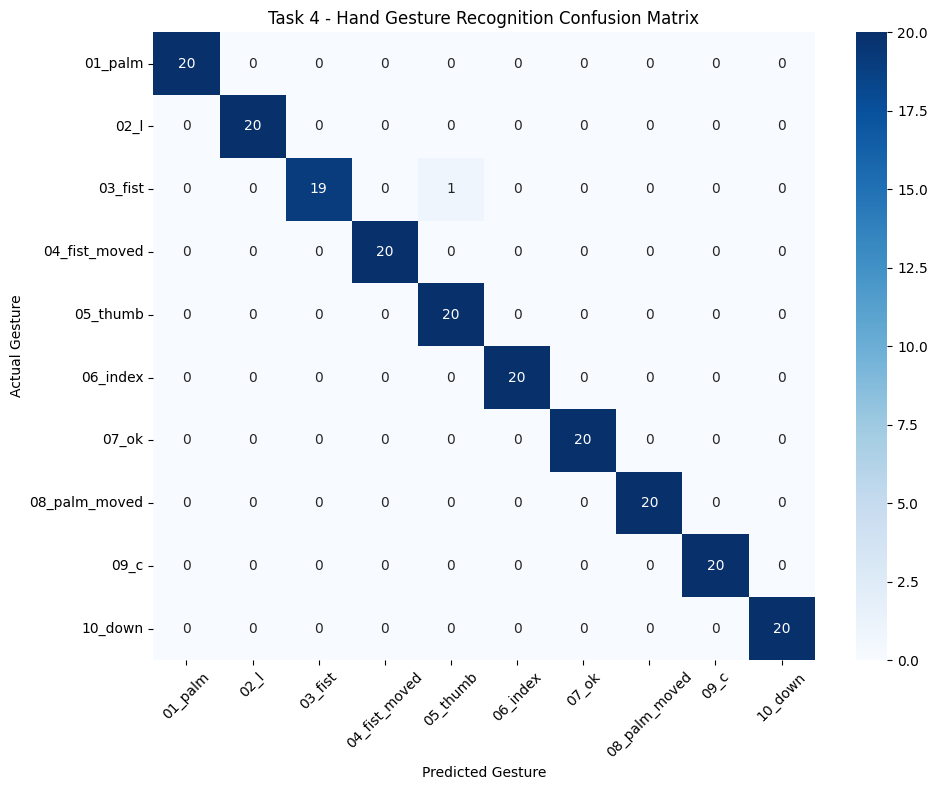

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_g, y_pred_g)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=gesture_names,
    yticklabels=gesture_names
)

plt.xlabel("Predicted Gesture")
plt.ylabel("Actual Gesture")
plt.title("Task 4 - Hand Gesture Recognition Confusion Matrix")

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
